In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Extract dataset
import os
zip_path = "/content/drive/MyDrive/AI Club DC/AI Club DC Project/SignAlphaSet.zip"
!unzip -q "$zip_path" -d "/content/"

# Verify it worked
print("Files in /content:")
print(os.listdir('/content'))

Mounted at /content/drive
Files in /content:
['.config', 'drive', 'SignAlphaSet', 'sample_data']


In [2]:
# Pytorch image loading

import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class ASLDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        # Folder names
        self.classes = sorted([d for d in os.listdir(root_dir)
                              if os.path.isdir(os.path.join(root_dir, d))])

        # Map letters to numbers
        self.class_to_idx = {letter: idx for idx, letter in enumerate(self.classes)}

        # List of image paths + their labels
        self.image_paths = []
        self.labels = []

        for letter in self.classes:
            folder_path = os.path.join(root_dir, letter)

            # Get all images in this letter's folder
            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    # Store full path
                    self.image_paths.append(os.path.join(folder_path, img_name))
                    # Store label number
                    self.labels.append(self.class_to_idx[letter])

        print(f"Found {len(self.image_paths)} images from {len(self.classes)} classes")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        # Get the path and label for this index
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load image and convert to RGB (3 channels)
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label


# Testing up till now
if __name__ == "__main__":
    DATA_PATH = "/content/SignAlphaSet"

    # Create dataset (no transforms yet, just load)
    dataset = ASLDataset(DATA_PATH, transform=None)

    print(f"\nTotal images: {len(dataset)}")
    print(f"Classes: {dataset.classes}")
    print(f"Class mapping: {dataset.class_to_idx}")

    # Load first image
    img, label = dataset[0]
    print(f"\nFirst image: size={img.size}, label={label} (letter={dataset.classes[label]})")

Found 26000 images from 26 classes

Total images: 26000
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Class mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}

First image: size=(296, 296), label=0 (letter=A)


Using sample image: /content/SignAlphaSet/A/A_268.jpg

Testing transforms

Original image: size=(296, 296), mode=RGB

After train_transform:
  Shape: torch.Size([3, 128, 128])
  Range: [-2.03, 1.68]
  Mean: -1.068

After val_transform:
  Shape: torch.Size([3, 128, 128])
  Range: [-2.10, 2.15]
  Mean: -0.725

 Transforms worked!

Generating augmentation examples...
Saved augmentation examples to 'augmentation_examples.png'


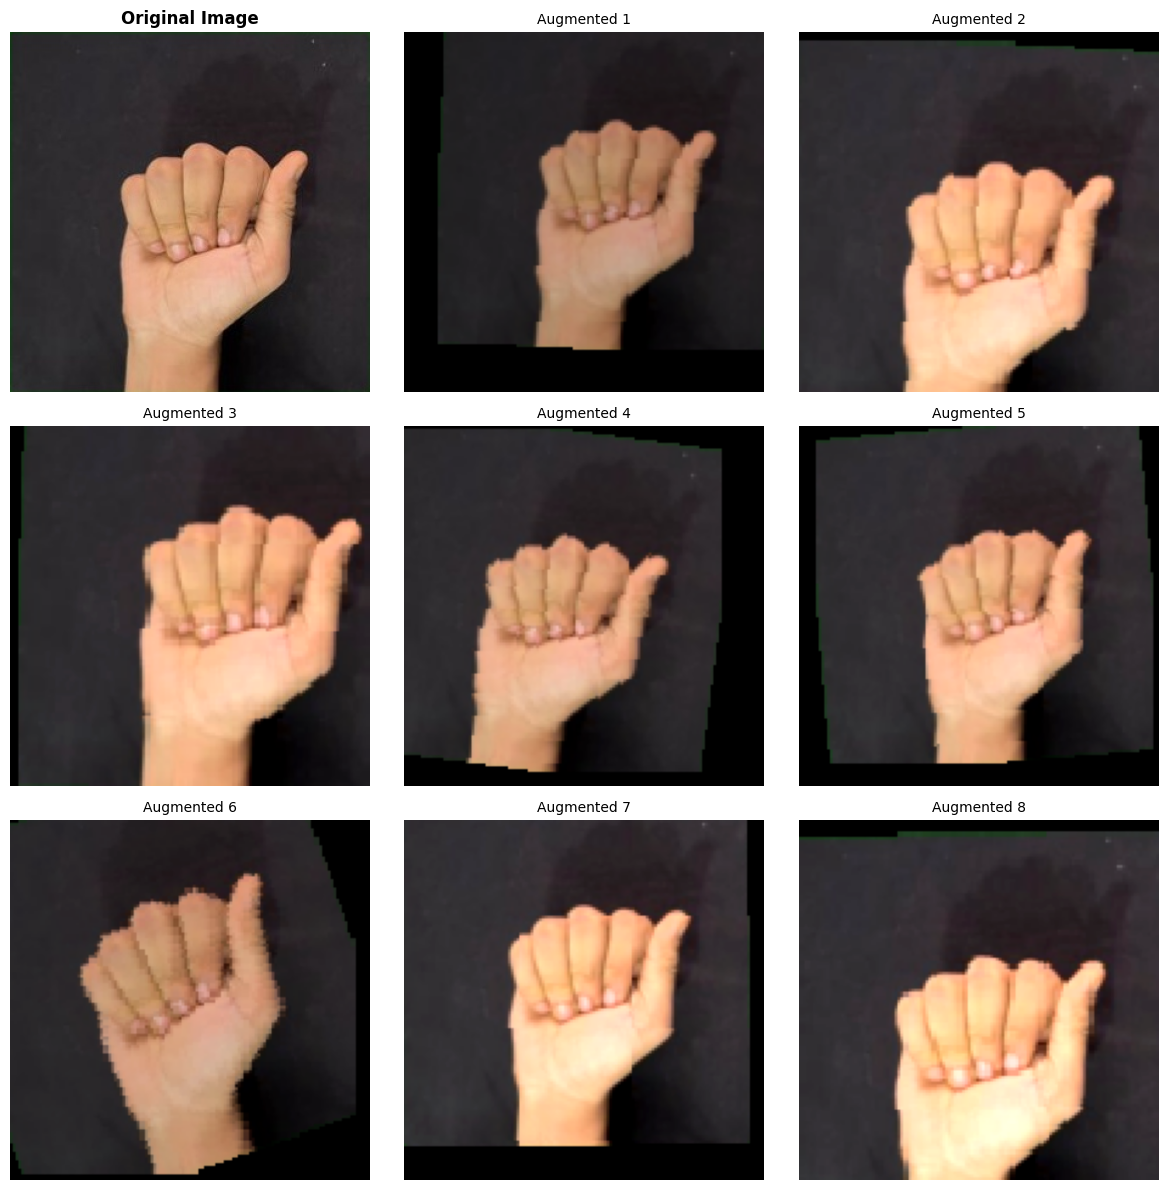

In [3]:
# Transformation and Aygmentation
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Augmenting
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.85, 1.15)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.15
    ),

    # Tensor forming and normalizing
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transforms
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Vizualise transforms
viz_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.85, 1.15)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.15
    ),
])


# Vizualise augments
def visualize_augmentations(image_path, num_examples=8):

    original_img = Image.open(image_path).convert('RGB')

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')


    for idx in range(1, 9):
        row = idx // 3
        col = idx % 3

        augmented = viz_transform(original_img)

        axes[row, col].imshow(augmented)
        axes[row, col].set_title(f"Augmented {idx}", fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
    print("Saved augmentation examples to 'augmentation_examples.png'")
    plt.show()


# Testing transforms
def test_transforms(image_path):

    print("Testing transforms")
    img = Image.open(image_path).convert('RGB')
    print(f"\nOriginal image: size={img.size}, mode={img.mode}")

    train_tensor = train_transform(img)
    print(f"\nAfter train_transform:")
    print(f"  Shape: {train_tensor.shape}")  # Should be [3, 128, 128]
    print(f"  Range: [{train_tensor.min():.2f}, {train_tensor.max():.2f}]")
    print(f"  Mean: {train_tensor.mean():.3f}")

    val_tensor = val_transform(img)
    print(f"\nAfter val_transform:")
    print(f"  Shape: {val_tensor.shape}")
    print(f"  Range: [{val_tensor.min():.2f}, {val_tensor.max():.2f}]")
    print(f"  Mean: {val_tensor.mean():.3f}")

    print("\n Transforms worked!")


# Executing
if __name__ == "__main__":
    import os

    DATA_PATH = "/content/SignAlphaSet"

    first_folder = sorted(os.listdir(DATA_PATH))[0]
    first_img = os.listdir(os.path.join(DATA_PATH, first_folder))[0]
    sample_img_path = os.path.join(DATA_PATH, first_folder, first_img)

    print(f"Using sample image: {sample_img_path}\n")

    test_transforms(sample_img_path)

    print("\nGenerating augmentation examples...")
    visualize_augmentations(sample_img_path, num_examples=8)


In [5]:
# Data Loading with split in train/val

import torch
from torch.utils.data import DataLoader, random_split

def get_data_loaders(data_path, batch_size=32, val_split=0.2, num_workers=2):
    print("Create data loaders")

    full_dataset = ASLDataset(data_path, transform=None)
    num_classes = len(full_dataset.classes)
    class_names = full_dataset.classes

    total_size = len(full_dataset)
    val_size = int(val_split * total_size)
    train_size = total_size - val_size

    print(f"\n Dataset Split:")
    print(f"   Total images: {total_size}")
    print(f"   Training: {train_size} ({100*(1-val_split):.0f}%)")
    print(f"   Validation: {val_size} ({100*val_split:.0f}%)")
    print(f"   Classes: {num_classes}")

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform

    print(f"\n Augmentation:")
    print(f"   Training: YES (rotation, zoom, brightness, etc.)")
    print(f"   Validation: NO (just resize + normalize)")

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    print(f"\n Batch Configuration:")
    print(f"   Batch size: {batch_size}")
    print(f"   Train batches: {len(train_loader)}")
    print(f"   Val batches: {len(val_loader)}")

    print("\n Data loaders created successfully!")

    return train_loader, val_loader, num_classes, class_names


# Inspection
def inspect_batch(loader, class_names):

    print("Inspect one batch")

    images, labels = next(iter(loader))

    print(f"\n Images:")
    print(f"   Shape: {images.shape}")
    print(f"   → [batch_size={images.shape[0]}, channels={images.shape[1]}, "
          f"height={images.shape[2]}, width={images.shape[3]}]")
    print(f"   Data type: {images.dtype}")
    print(f"   Value range: [{images.min():.2f}, {images.max():.2f}]")

    print(f"\n  Labels:")
    print(f"   Shape: {labels.shape}")
    print(f"   First 10 labels: {labels[:10].tolist()}")

    # Show which letters these correspond to
    letter_samples = [class_names[label] for label in labels[:10]]
    print(f"   First 10 letters: {letter_samples}")

    print(f"\n Batch structure proper!")


# Execution
if __name__ == "__main__":
    # Configuration
    DATA_PATH = "/content/SignAlphaSet"
    BATCH_SIZE = 32
    VAL_SPLIT = 0.2

    # Create data loaders
    train_loader, val_loader, num_classes, class_names = get_data_loaders(
        data_path=DATA_PATH,
        batch_size=BATCH_SIZE,
        val_split=VAL_SPLIT,
        num_workers=2
    )

    # Inspect training batch
    print("\n TRAINING BATCH")
    inspect_batch(train_loader, class_names)

    # Inspect validation batch
    print("\n VALIDATION BATCH")
    inspect_batch(val_loader, class_names)

Create data loaders
Found 26000 images from 26 classes

 Dataset Split:
   Total images: 26000
   Training: 20800 (80%)
   Validation: 5200 (20%)
   Classes: 26

 Augmentation:
   Training: YES (rotation, zoom, brightness, etc.)
   Validation: NO (just resize + normalize)

 Batch Configuration:
   Batch size: 32
   Train batches: 650
   Val batches: 163

 Data loaders created successfully!

 TRAINING BATCH
Inspect one batch

 Images:
   Shape: torch.Size([32, 3, 128, 128])
   → [batch_size=32, channels=3, height=128, width=128]
   Data type: torch.float32
   Value range: [-2.12, 2.25]

  Labels:
   Shape: torch.Size([32])
   First 10 labels: [21, 3, 19, 0, 3, 20, 0, 22, 8, 6]
   First 10 letters: ['V', 'D', 'T', 'A', 'D', 'U', 'A', 'W', 'I', 'G']

 Batch structure proper!

 VALIDATION BATCH
Inspect one batch

 Images:
   Shape: torch.Size([32, 3, 128, 128])
   → [batch_size=32, channels=3, height=128, width=128]
   Data type: torch.float32
   Value range: [-2.12, 2.23]

  Labels:
   Sh

In [6]:
# Model Architecture: ASL-ResNeXt

import torch
import torch.nn as nn
import torch.nn.functional as F

class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // 16),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // 16, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        attn = self.gap(x).view(b, c)
        attn = self.fc(attn).view(b, c, 1, 1)
        return x * attn.expand_as(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.attention = SpatialAttention(out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.depthwise(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.pointwise(out)
        out = self.bn2(out)

        out = self.attention(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ASLResNeXt(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Stages
        self.stage2 = self._make_stage(64, 64, 2, stride=1)
        self.stage3 = self._make_stage(64, 128, 2, stride=2)
        self.stage4 = self._make_stage(128, 256, 2, stride=2)
        self.stage5 = self._make_stage(256, 512, 2, stride=2)

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))

        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


if __name__ == "__main__":
    model = ASLResNeXt(num_classes=26)
    print(f"Model parameters: {count_parameters(model):,}")

    # Test forward pass
    x = torch.randn(1, 3, 128, 128)
    out = model(x)
    print(f"Output shape: {out.shape}")

Model parameters: 859,410
Output shape: torch.Size([1, 26])


In [7]:
# Training Loop

import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from collections import defaultdict

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, num_classes=26):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Per-class accuracy
            for label, pred in zip(labels, predicted):
                if label == pred:
                    class_correct[label] += 1
                class_total[label] += 1

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    per_class_acc = [100. * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
                     for i in range(num_classes)]

    return epoch_loss, epoch_acc, per_class_acc, all_preds, all_labels


def train_model(model, train_loader, val_loader, num_epochs, device, class_names):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

    history = defaultdict(list)
    best_val_acc = 0.0
    patience = 5
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        print(f'\nEpoch {epoch}/{num_epochs}')

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc, per_class_acc, _, _ = validate(model, val_loader, criterion, device)

        # Update scheduler
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        # Track history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        print(f'LR: {current_lr:.6f}')

        # Per-class accuracy every 5 epochs
        if epoch % 5 == 0:
            print('\nPer-class accuracy:')
            for i, acc in enumerate(per_class_acc):
                print(f'{class_names[i]}: {acc:.1f}%', end='  ')
                if (i + 1) % 13 == 0:
                    print()
            print()

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'✓ Saved best model (Val Acc: {val_acc:.2f}%)')
            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered (no improvement for {patience} epochs)')
            break

    # Save final model
    torch.save(model.state_dict(), 'final_model.pth')

    return history, best_val_acc

In [8]:
# Execute Training

import torch

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

# Create model
model = ASLResNeXt(num_classes=26).to(device)
print(f'\nModel: ASL-ResNeXt')
print(f'Parameters: {count_parameters(model):,}')

# Train
print("Start to train")

history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=25,
    device=device,
    class_names=class_names
)

print("Training is completed.")
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB

Model: ASL-ResNeXt
Parameters: 859,410
Start to train

Epoch 1/25


Validation: 100%|██████████| 163/163 [00:09<00:00, 16.62it/s]


Train Loss: 3.1326 | Train Acc: 14.96%
Val Loss: 2.9576 | Val Acc: 43.02%
LR: 0.001000
✓ Saved best model (Val Acc: 43.02%)

Epoch 2/25


Validation: 100%|██████████| 163/163 [00:09<00:00, 16.54it/s]


Train Loss: 2.7070 | Train Acc: 39.25%
Val Loss: 2.3855 | Val Acc: 57.12%
LR: 0.001000
✓ Saved best model (Val Acc: 57.12%)

Epoch 3/25


...

Train Loss: 0.4725 | Train Acc: 94.05%
Val Loss: 0.3365 | Val Acc: 98.37%
LR: 0.000010

Epoch 24/25


Validation: 100%|██████████| 163/163 [00:11<00:00, 14.60it/s]


Train Loss: 0.4732 | Train Acc: 94.14%
Val Loss: 0.3399 | Val Acc: 98.35%
LR: 0.000001

Epoch 25/25


Validation: 100%|██████████| 163/163 [00:11<00:00, 14.71it/s]

Train Loss: 0.4742 | Train Acc: 94.04%
Val Loss: 0.3431 | Val Acc: 98.48%
LR: 0.000001

Per-class accuracy:
A: 100.0%  B: 100.0%  C: 99.5%  D: 98.6%  E: 98.7%  F: 100.0%  G: 100.0%  H: 99.5%  I: 99.5%  J: 100.0%  K: 100.0%  L: 98.6%  M: 93.7%  
N: 100.0%  O: 100.0%  P: 93.8%  Q: 92.6%  R: 100.0%  S: 95.6%  T: 95.3%  U: 100.0%  V: 95.8%  W: 100.0%  X: 100.0%  Y: 100.0%  Z: 99.5%  


Early stopping triggered (no improvement for 5 epochs)
Training is completed.
Best Validation Accuracy: 98.67%



Loading best model...


Validation: 100%|██████████| 163/163 [00:10<00:00, 15.00it/s]


Final evaluation
Validation Loss: 0.3441
Validation Accuracy: 98.67%

Per-class Accuracy:
A: 100.0%  B: 100.0%  C: 99.5%  D: 99.1%  E: 99.2%  F: 100.0%  G: 100.0%  H: 99.5%  I: 99.5%  J: 100.0%  K: 100.0%  L: 98.6%  M: 94.1%  
N: 100.0%  O: 100.0%  P: 99.0%  Q: 90.2%  R: 100.0%  S: 96.7%  T: 94.8%  U: 100.0%  V: 96.3%  W: 100.0%  X: 100.0%  Y: 100.0%  Z: 99.5%  


Hardest Letters:
Q: 90.2%
M: 94.1%
T: 94.8%
V: 96.3%
S: 96.7%

✓ Saved confusion_matrix.png


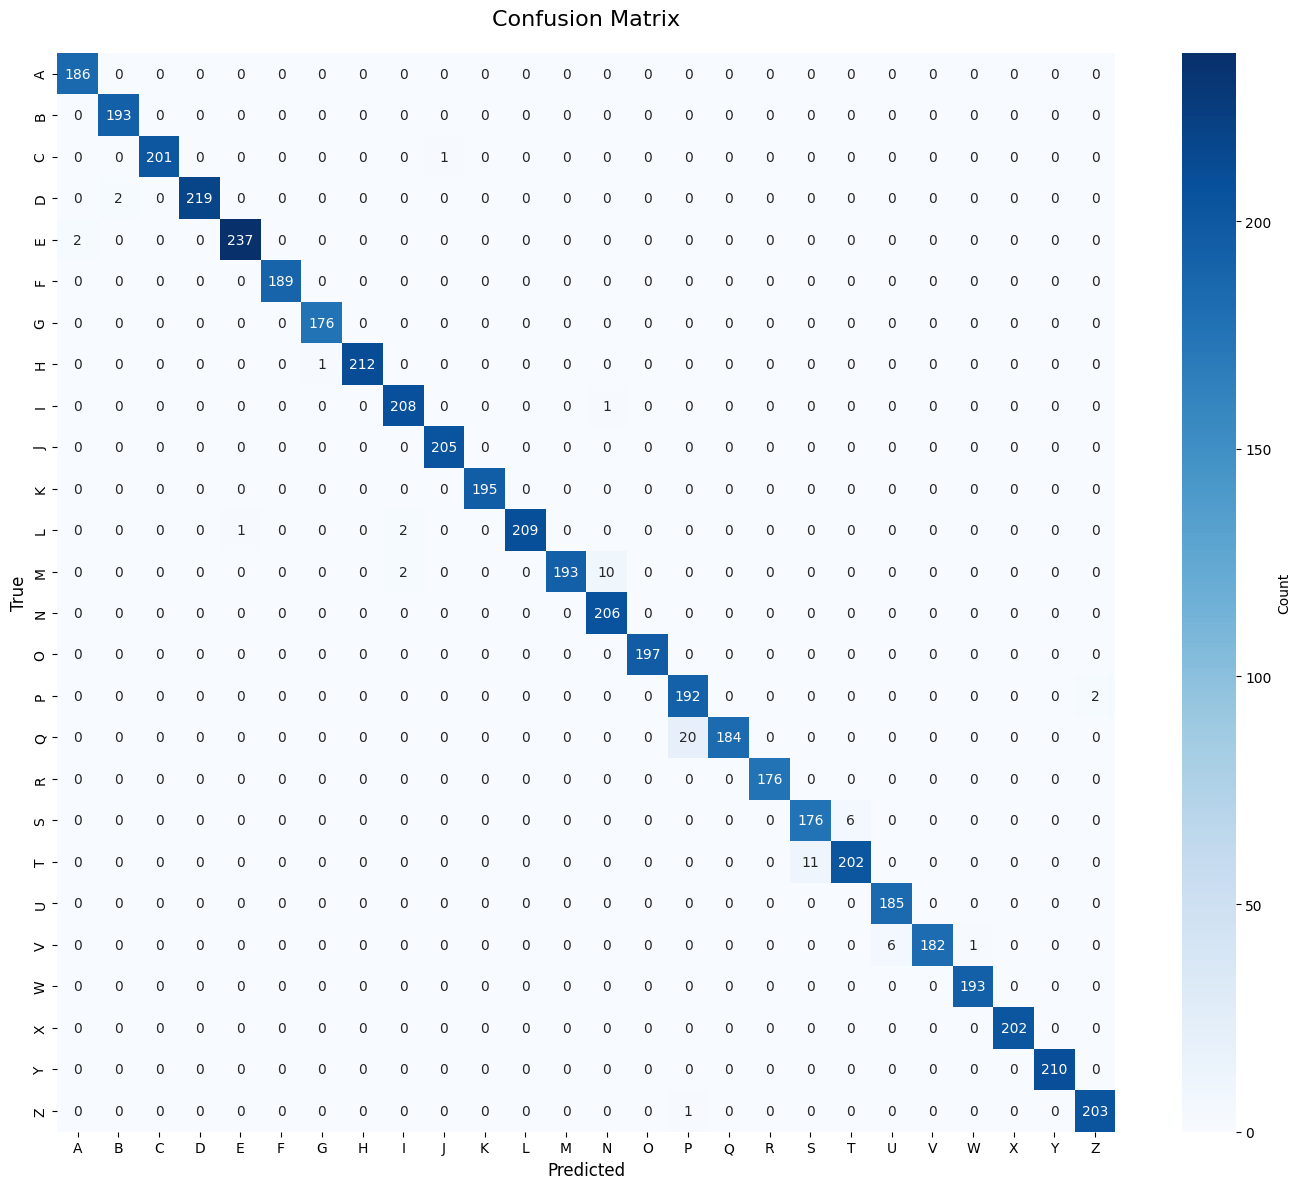


Most Confused Pairs:
Q → P: 20 times (9.8%)
T → S: 11 times (5.2%)
M → N: 10 times (4.9%)
S → T: 6 times (3.3%)
V → U: 6 times (3.2%)

✓ Saved predictions.png


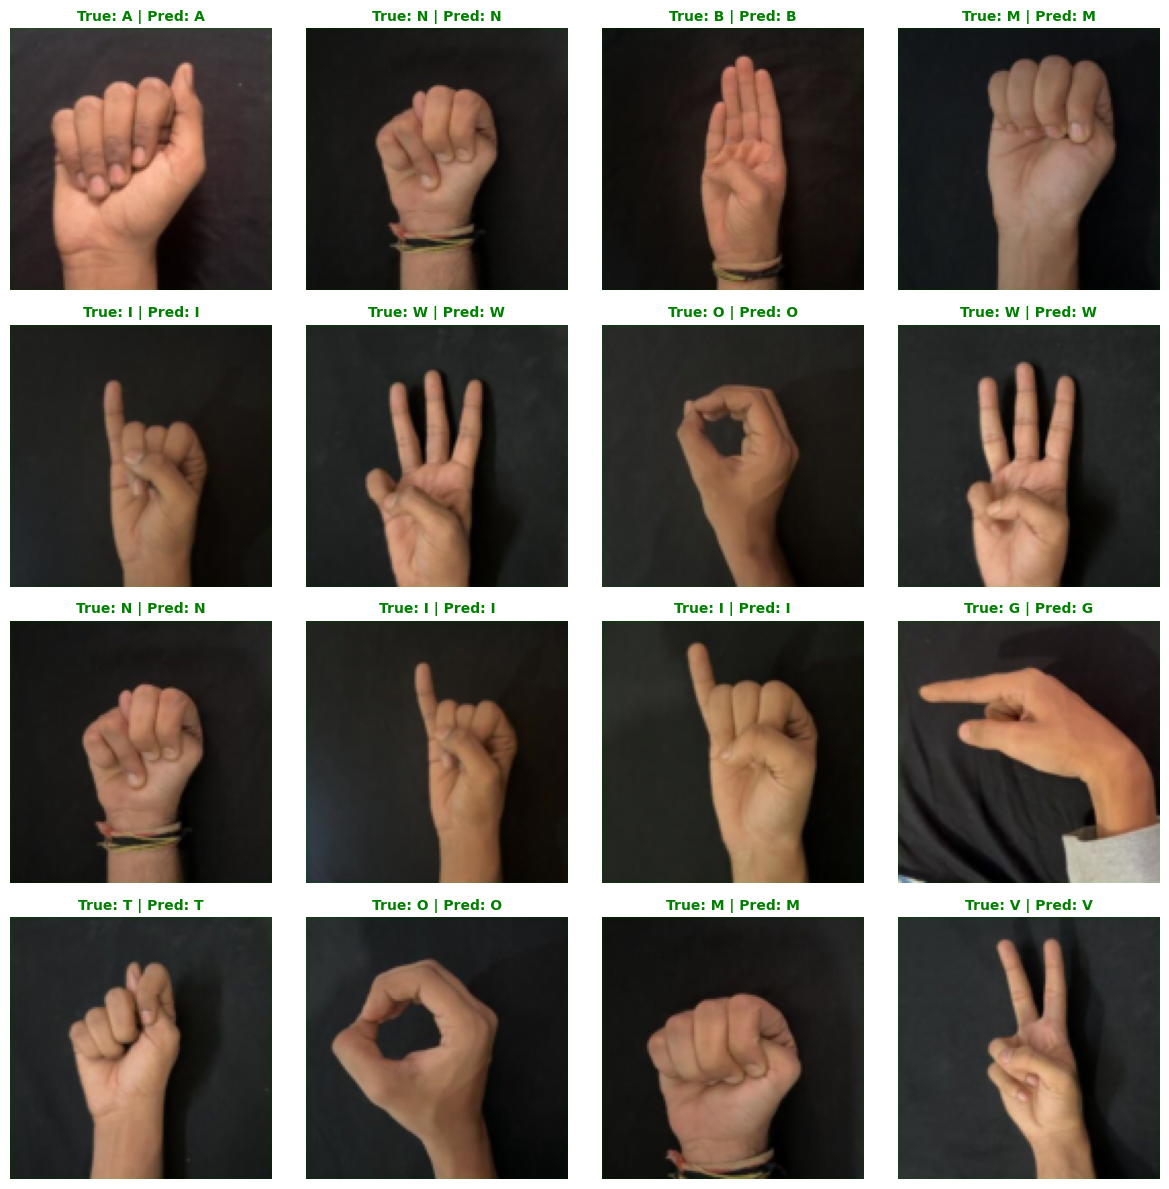

In [11]:
# Evaluation

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, loader, device, class_names):
    criterion = nn.CrossEntropyLoss()
    val_loss, val_acc, per_class_acc, all_preds, all_labels = validate(
        model, loader, criterion, device, len(class_names)
    )

    print("Final evaluation")
    print(f'Validation Loss: {val_loss:.4f}')
    print(f'Validation Accuracy: {val_acc:.2f}%')

    print('\nPer-class Accuracy:')
    for i, (name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f'{name}: {acc:.1f}%', end='  ')
        if (i + 1) % 13 == 0:
            print()
    print()

    # Find hardest letters
    worst_indices = np.argsort(per_class_acc)[:5]
    print('\nHardest Letters:')
    for idx in worst_indices:
        print(f'{class_names[idx]}: {per_class_acc[idx]:.1f}%')

    return all_preds, all_labels, per_class_acc


def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=16, pad=20)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    print('\n✓ Saved confusion_matrix.png')
    plt.show()

    # Most confused pairs
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    np.fill_diagonal(cm_norm, 0)

    print('\nMost Confused Pairs:')
    for _ in range(5):
        i, j = np.unravel_index(cm_norm.argmax(), cm_norm.shape)
        count = cm[i, j]
        print(f'{class_names[i]} → {class_names[j]}: {count} times ({cm_norm[i,j]*100:.1f}%)')
        cm_norm[i, j] = 0


def visualize_predictions(model, loader, device, class_names, num_samples=16):
    model.eval()
    images_list = []
    labels_list = []
    preds_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            images_list.extend(images.cpu())
            labels_list.extend(labels.cpu())
            preds_list.extend(preds.cpu())

            if len(images_list) >= num_samples:
                break

    # Denormalize images
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for idx, ax in enumerate(axes.flat):
        if idx >= num_samples:
            break

        img = images_list[idx] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        true_label = class_names[labels_list[idx]]
        pred_label = class_names[preds_list[idx]]
        correct = labels_list[idx] == preds_list[idx]

        ax.imshow(img)
        ax.axis('off')
        color = 'green' if correct else 'red'
        ax.set_title(f'True: {true_label} | Pred: {pred_label}',
                    color=color, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    print('\n✓ Saved predictions.png')
    plt.show()


# Run evaluation
print('\nLoading best model...')
model.load_state_dict(torch.load('best_model.pth'))

all_preds, all_labels, per_class_acc = evaluate_model(model, val_loader, device, class_names)
plot_confusion_matrix(all_labels, all_preds, class_names)
visualize_predictions(model, val_loader, device, class_names, num_samples=16)


✓ Saved training_curves.png


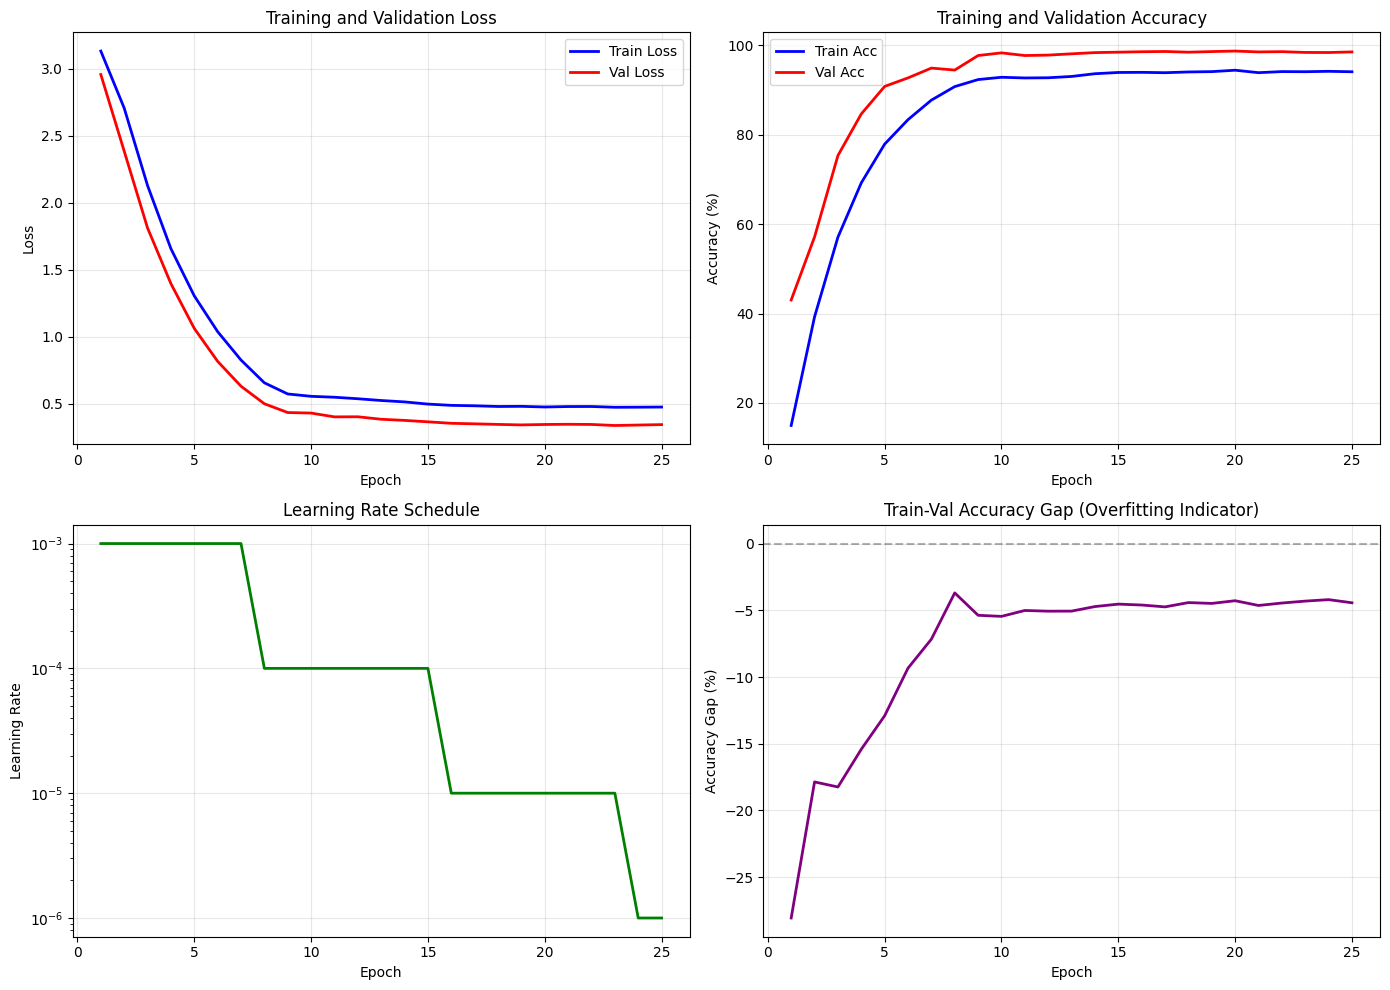


✓ Saved per_class_accuracy.png


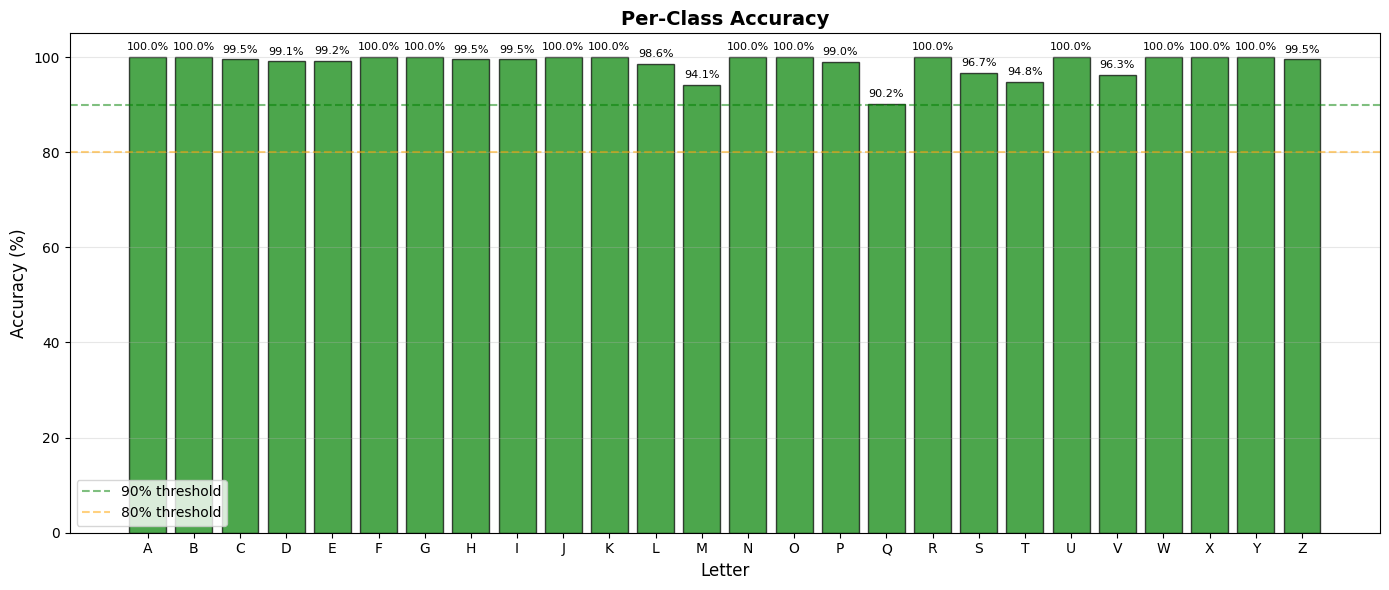

Summary
Final Train Accuracy: 94.04%
Final Val Accuracy: 98.48%
Best Val Accuracy: 98.67%
Total Epochs: 25

Files saved:
  - best_model.pth
  - final_model.pth
  - training_curves.png
  - confusion_matrix.png
  - per_class_accuracy.png
  - predictions.png


In [10]:
# Training Visualizations

import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 0].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)

    # Overfitting Gap
    gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[1, 1].plot(epochs, gap, 'purple', linewidth=2)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy Gap (%)')
    axes[1, 1].set_title('Train-Val Accuracy Gap (Overfitting Indicator)')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    print('\n✓ Saved training_curves.png')
    plt.show()


def plot_per_class_accuracy(per_class_acc, class_names):
    fig, ax = plt.subplots(figsize=(14, 6))

    colors = ['green' if acc >= 90 else 'orange' if acc >= 80 else 'red'
              for acc in per_class_acc]

    bars = ax.bar(class_names, per_class_acc, color=colors, alpha=0.7, edgecolor='black')

    ax.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
    ax.axhline(y=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')

    ax.set_xlabel('Letter', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    # Add value labels
    for bar, acc in zip(bars, per_class_acc):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
    print('\n✓ Saved per_class_accuracy.png')
    plt.show()


# Generate plots
plot_training_curves(history)
plot_per_class_accuracy(per_class_acc, class_names)

# Summary
print("Summary")
print(f'Final Train Accuracy: {history["train_acc"][-1]:.2f}%')
print(f'Final Val Accuracy: {history["val_acc"][-1]:.2f}%')
print(f'Best Val Accuracy: {best_val_acc:.2f}%')
print(f'Total Epochs: {len(history["train_loss"])}')
print(f'\nFiles saved:')
print('  - best_model.pth')
print('  - final_model.pth')
print('  - training_curves.png')
print('  - confusion_matrix.png')
print('  - per_class_accuracy.png')
print('  - predictions.png')